# Gemeindegrenzen der Steiermark

Univariate descriptive analysis for the master's thesis.

**Source:** OGD/Gemeindegrenzen.zip

In [1]:
import os
import sys
os.chdir(r"D:\CO2_Masterarbeit\CO2_Masterarbeit")
sys.path.insert(0, r"D:\CO2_Masterarbeit\CO2_Masterarbeit\FIG")

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from plotting.apa7 import set_apa7_style, new_figure, save_apa7, BAR_KWARGS, HIST_KWARGS, LINE_KWARGS

set_apa7_style()

In [2]:
municipalities = gpd.read_file("OGD/Gemeindegrenzen.zip")
municipalities["FLAECHE_HA"].describe()

d:\CO2_Masterarbeit\CO2_Masterarbeit\.venv\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: Value '12746,516106705474.000000000000' of field Gemeindegrenzen.FLAECHE_HA parsed incompletely to real 12746.
  return ogr_read(
d:\CO2_Masterarbeit\CO2_Masterarbeit\.venv\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: Value '1557,8285611642518.000000000000' of field Gemeindegrenzen.FLAECHE_HA parsed incompletely to real 1557.
  return ogr_read(
d:\CO2_Masterarbeit\CO2_Masterarbeit\.venv\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: Value '1986,7065126925297.000000000000' of field Gemeindegrenzen.FLAECHE_HA parsed incompletely to real 1986.
  return ogr_read(
d:\CO2_Masterarbeit\CO2_Masterarbeit\.venv\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: Value '615,5113923390799.0000000000000' of field Gemeindegrenzen.FLAECHE_HA parsed incompletely to real 615.
  return ogr_read(
d:\CO2_Masterarbeit\CO2_Masterarbeit\.venv\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning:

count      285.000000
mean      5754.168421
std       5757.828433
min        419.000000
25%       2075.000000
50%       3802.000000
75%       7565.000000
max      41353.000000
Name: FLAECHE_HA, dtype: float64

## Municipal area

Area is right-skewed, hence the logarithmic x-axis.

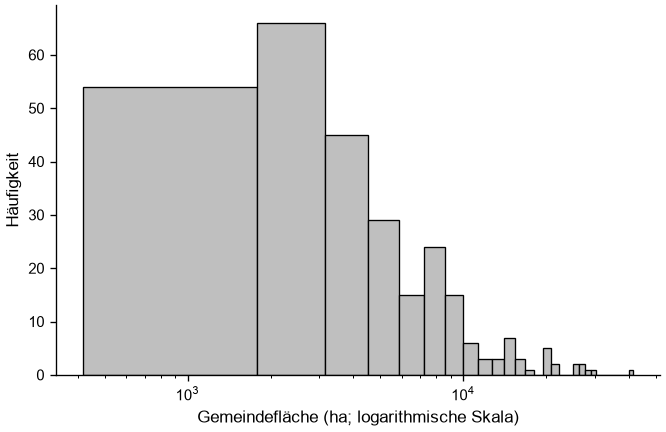

In [3]:
fig, ax = new_figure()
ax.hist(municipalities["FLAECHE_HA"].dropna(), bins=30, **HIST_KWARGS)
ax.set_xscale("log")
ax.set(xlabel="Gemeindefläche (ha; logarithmische Skala)", ylabel="Häufigkeit")
save_apa7(fig, "FIG/Gemeindegrenzen/figure_1_municipal_area_distribution.png")
save_apa7(fig, "FIG/Gemeindegrenzen/figure_1_municipal_area_distribution.svg")
plt.show()

## Municipalities by district

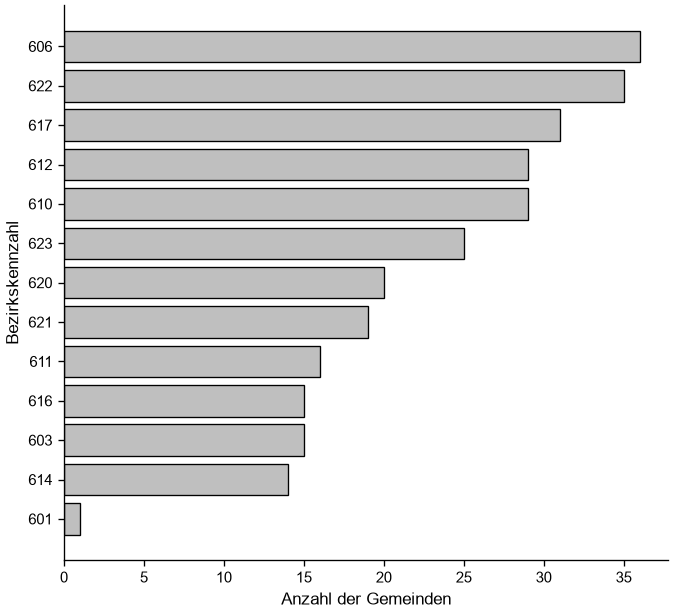

In [4]:
counts = municipalities["BEZNR6"].value_counts().sort_values()
fig, ax = new_figure(6.5, 6)
ax.barh(counts.index, counts.values, **BAR_KWARGS)
ax.set(xlabel="Anzahl der Gemeinden", ylabel="Bezirkskennzahl")
save_apa7(fig, "FIG/Gemeindegrenzen/figure_2_municipalities_by_district.png")
save_apa7(fig, "FIG/Gemeindegrenzen/figure_2_municipalities_by_district.svg")
plt.show()